# Capitulo 3. Clasificación

Proyecto de clasificación, para diagnosticar medicamenttos basándose en las caracteristicas de los pacientes.

## <span style="color:green">1. Descargar los datos 📉</span>

EN ESTE PROYECTO SOLO VAMOS A NECESITAR LA BASE DE DATOS drug300.csv.💊

https://github.com/a2Proyectos/MachineLearning_Data



In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/a2Proyectos/MachineLearning_Data/main/"
LONDON_SALARY = "Capitulo_3/drug200.csv"
def extraer_datos(url, basedeDatos):
    csv_path = url + basedeDatos
    return pd.read_csv(csv_path)

df_drugs = extraer_datos(DOWNLOAD_ROOT, LONDON_SALARY)

In [6]:
df_drugs.info()
print(df_drugs.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB
   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  DrugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  DrugY


## <span style="color:green">2. Análisis de cada Variable</span>

Max Age: 74
Min Age: 15


<Figure size 900x500 with 0 Axes>

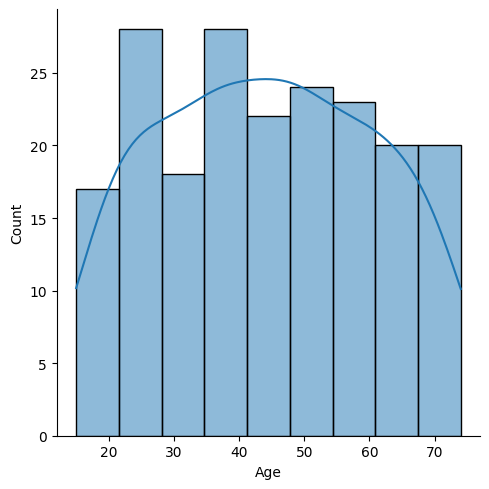

Sex
M    104
F     96
Name: count, dtype: int64


In [7]:
print("Max Age:", df_drugs.Age.max())
print("Min Age:", df_drugs.Age.min())
plt.figure(figsize=(9,5))
sns.displot(df_drugs.Age, kde=True)
plt.show()

print(df_drugs.Sex.value_counts())


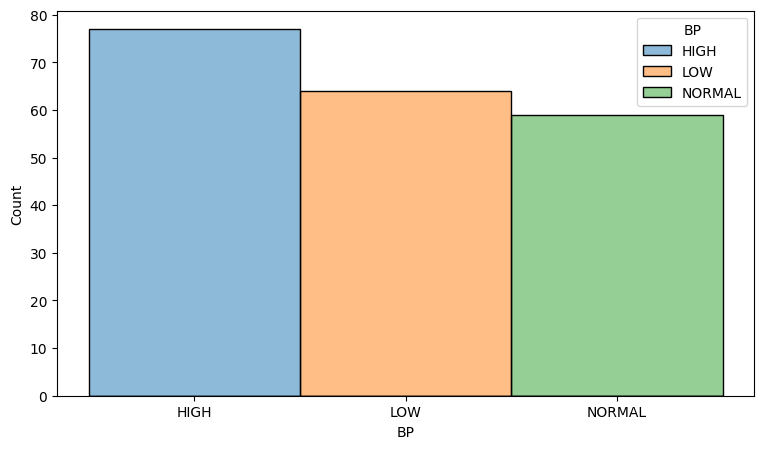

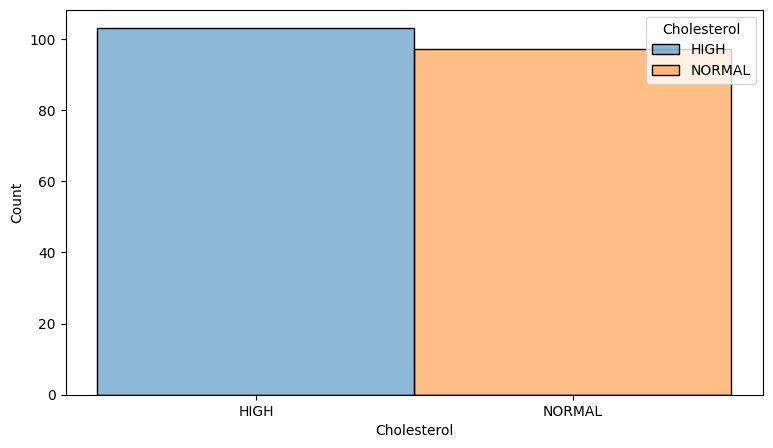

In [8]:
plt.figure(figsize=(9,5))
sns.histplot(data=df_drugs, x="BP", hue="BP")
plt.show()
plt.figure(figsize=(9,5))
sns.histplot(data=df_drugs, x="Cholesterol", hue="Cholesterol")
plt.show()


<Figure size 900x500 with 0 Axes>

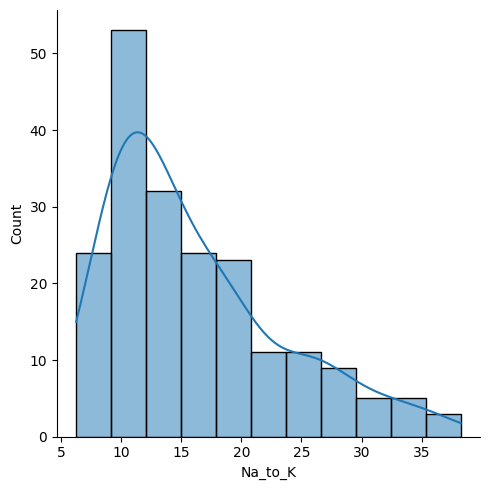

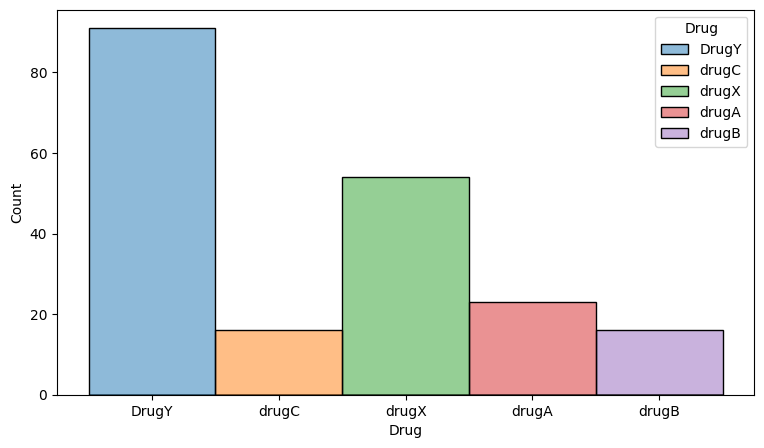

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(9,5))
sns.displot(df_drugs.Na_to_K, kde=True)
plt.show()

plt.figure(figsize=(9,5))
sns.histplot(data=df_drugs, x="Drug", hue="Drug")
plt.show()
print(df_drugs.Drug.value_counts())


***

## <span style="color:green">3. Análisis de Relación entre Variables</span>


C:\Users\vale2\AppData\Local\Temp\ipykernel_16180\1260030404.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="Drug", y="Age", data=df_drugs, palette=palette)


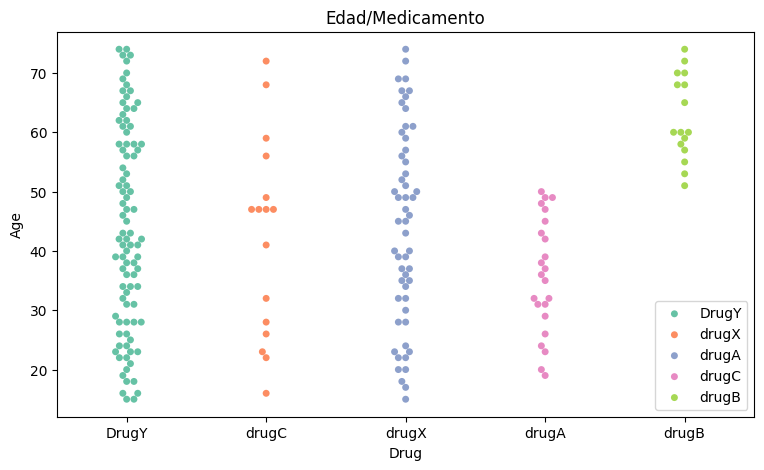

In [10]:
plt.figure(figsize=(9,5))
palette = sns.color_palette("Set2", n_colors=len(df_drugs.Drug.value_counts().index))
sns.swarmplot(x="Drug", y="Age", data=df_drugs, palette=palette)
plt.legend(df_drugs.Drug.value_counts().index)
plt.title("Edad/Medicamento")
plt.show()


    Drug Sex  Count
0  DrugY   F     47
1  DrugY   M     44
2  drugA   F      9
3  drugA   M     14
4  drugB   F      6
5  drugB   M     10
6  drugC   F      7
7  drugC   M      9
8  drugX   F     27
9  drugX   M     27


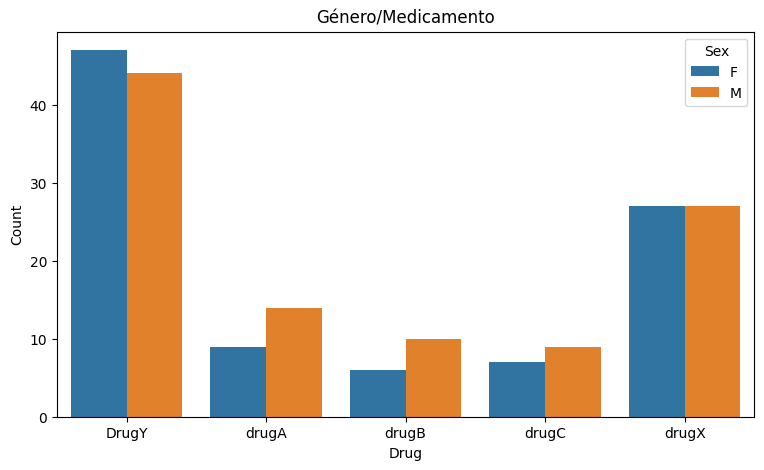

In [11]:
df_Sex_Drug = df_drugs.groupby(["Drug","Sex"]).size().reset_index(name="Count")
print(df_Sex_Drug)
plt.figure(figsize=(9,5))
sns.barplot(x="Drug", y="Count", hue="Sex", data=df_Sex_Drug)
plt.title("Género/Medicamento")
plt.show()

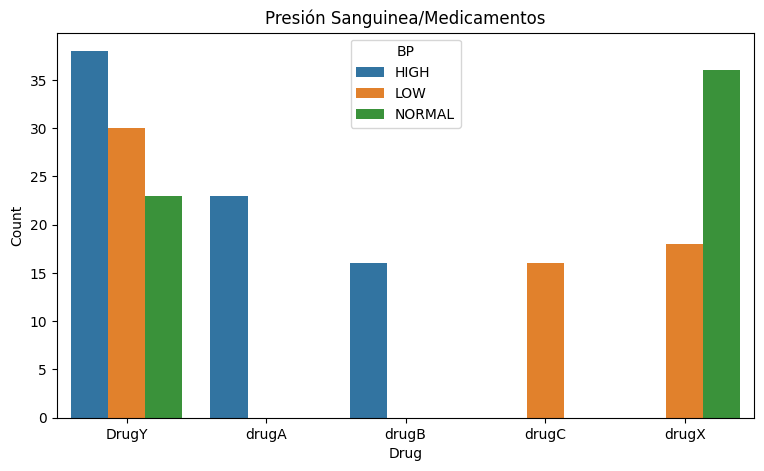

In [12]:
df_BP_Drug = df_drugs.groupby(["Drug","BP"]).size().reset_index(name="Count")
plt.figure(figsize=(9,5))
sns.barplot(x="Drug", y="Count", hue="BP", data=df_BP_Drug)
plt.title("Presión Sanguinea/Medicamentos")
plt.show()


    Drug Cholesterol  Count
0  DrugY        HIGH     47
1  DrugY      NORMAL     44
2  drugA        HIGH     12
3  drugA      NORMAL     11
4  drugB        HIGH      8
5  drugB      NORMAL      8
6  drugC        HIGH     16
7  drugX        HIGH     20
8  drugX      NORMAL     34


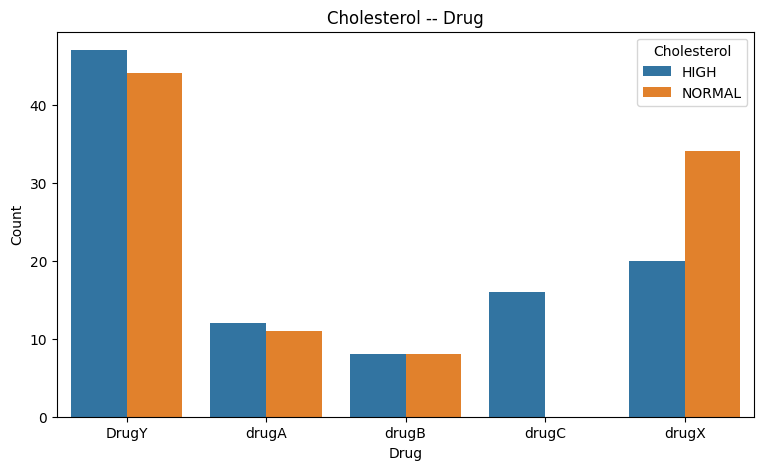

In [13]:
df_CH_Drug = df_drugs.groupby(["Drug","Cholesterol"]).size().reset_index(name="Count")
print(df_CH_Drug)
plt.figure(figsize=(9,5))
sns.barplot(x="Drug", y="Count", hue="Cholesterol", data=df_CH_Drug)
plt.title("Cholesterol -- Drug")
plt.show()


C:\Users\vale2\AppData\Local\Temp\ipykernel_16180\2723287191.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="Drug", y="Na_to_K", data=df_drugs, palette=palette)


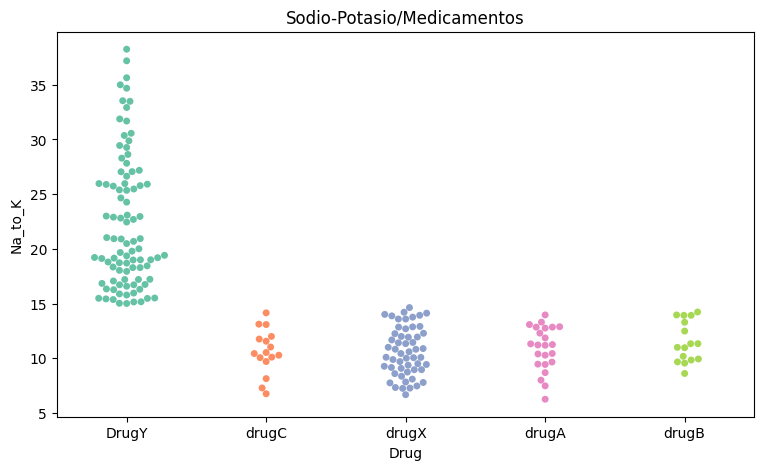

In [14]:

plt.figure(figsize=(9,5))
palette = sns.color_palette("Set2", n_colors=len(df_drugs.Drug.value_counts().index))
sns.swarmplot(x="Drug", y="Na_to_K", data=df_drugs, palette=palette)
plt.title("Sodio-Potasio/Medicamentos")
plt.show()


***

## <span style="color:green">4. Limpieza y Separación de Datos</span>


In [15]:
from sklearn.preprocessing import LabelEncoder
df = df_drugs.copy()
def label_encoder(datos_categoria):
    le = LabelEncoder()
    df_drugs[datos_categoria] = le.fit_transform(df_drugs[datos_categoria])
variables = ["Sex","BP","Cholesterol","Na_to_K","Drug"]
for l in variables:
    label_encoder(l)
print(df_drugs.head())

x = df_drugs.drop(["Drug"], axis=1)
y = df_drugs["Drug"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)## Utilizar LabelEncoder para procesar variables alfanuméricas como el sexo, BP, Colesterol, étc



   Age  Sex  BP  Cholesterol  Na_to_K  Drug
0   23    0   0            0      167     0
1   47    1   1            0       89     3
2   47    1   1            0       43     3
3   28    0   2            0       10     4
4   61    0   1            0      133     0


El 20% de los datos, serán de prueba. Shuffle será true. Semilla de Aleatoriedad=42

***

## <span style="color:green">5. Modelo de Clasificación Binario</span>


In [16]:
y_train_c = (y_train == 0)
y_test_c = (y_test == 0)
print(y_train_c.value_counts())

from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier(random_state=42)
sgd.fit(x_train, y_train_c)

print(sgd.predict([[47,1,1,0,8]]))


Drug
False    84
True     76
Name: count, dtype: int64
[False]


c:\Users\vale2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


Empezaremos con la medicina Y porque es la más popular y, por ende la más fácil de predecir

👀: para saber que le esta yendo bien al modelo tienen que coincidir los resultados

***

## <span style="color:green">6. Medidas de desempeño</span>


### <span style="color:blue">6.1 Exactitud</span>

In [17]:
from sklearn.model_selection import cross_val_score, cross_val_predict
print(cross_val_score(sgd, x_train, y_train_c, cv=3, scoring="accuracy"))

y_train_pred = cross_val_predict(sgd, x_train, y_train_c, cv=3)
print(y_train_pred)

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
print(confusion_matrix(y_train_c, y_train_pred))

p = precision_score(y_train_c, y_train_pred)
r = recall_score(y_train_c, y_train_pred)
print("Precisión:", p, "Recall:", r)

from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(x_train, y_train_c)
y_train_pred_rf = cross_val_predict(rfc, x_train, y_train_c, cv=3)
print(confusion_matrix(y_train_c, y_train_pred_rf))
p_rf = precision_score(y_train_c, y_train_pred_rf)
r_rf = recall_score(y_train_c, y_train_pred_rf)
print("Precisión RF:", p_rf, "Recall RF:", r_rf)
print("F1 RF:", f1_score(y_train_c, y_train_pred_rf))

[0.7962963  0.73584906 0.71698113]
[ True False False  True  True  True  True  True  True  True False  True
 False  True False  True False  True  True  True  True  True False  True
 False  True  True  True  True False False False  True  True  True  True
  True False  True False False  True  True False False  True False False
  True False  True  True  True  True  True  True  True  True False  True
  True False False False  True False  True  True False  True  True  True
  True  True  True  True  True  True  True  True  True False False  True
  True  True  True  True False  True  True False  True  True  True  True
 False False  True  True  True  True  True  True  True  True False False
  True  True False  True  True  True  True  True False  True  True  True
  True  True  True  True False False  True  True  True False  True  True
  True  True  True  True False  True  True False  True  True False  True
 False False  True False  True  True  True  True  True  True  True  True
  True  True  Tr

 
**cv:** número de dobleses 

**scoring:** accuracy (será nuestra medida de desempeño)  

***

### <span style="color:blue">6.2 Matriz de Confusión</span>

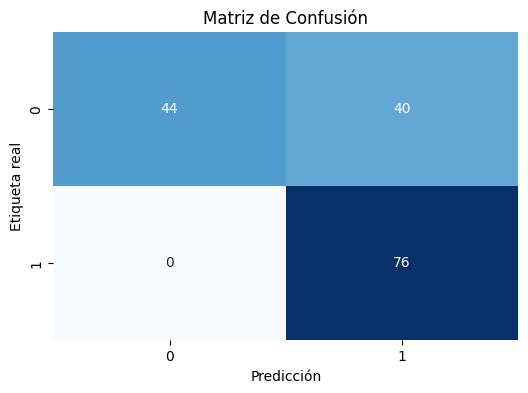

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt




conf_mx = confusion_matrix(y_train_c, y_train_pred)

plt.figure(figsize=(6,4))
sns.heatmap(conf_mx, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de Confusión')
plt.show()

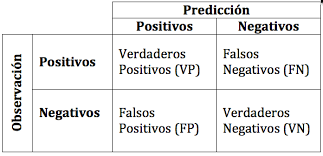

**Verdaderos Negativos**: esquina superior izquierda 

**Falsos positivos**: esquina superior derecha

**Falsos Negativos**: esquina inferior izquierda

**Verdaderos Positivos**: esquina inferior derecha 

***

### <span style="color:blue">6.3 Precision y Recall</span>

In [21]:
from sklearn.metrics import precision_score, recall_score

# Calculamos precisión y recall
precision = precision_score(y_train_c, y_train_pred)
recall = recall_score(y_train_c, y_train_pred)

print(f'Precisión: {precision:.2f}')
print(f'Recall: {recall:.2f}')


Precisión: 0.66
Recall: 1.00


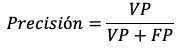

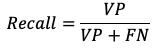

In [23]:
from sklearn.metrics import f1_score

f1 = f1_score(y_train_c, y_train_pred)
print(f'F1 Score: {f1:.2f}')


F1 Score: 0.79


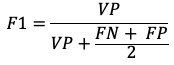

***

### <span style="color:blue">6.4 Umbral Precision y Recall</span>

In [22]:
from sklearn.metrics import f1_score

f1 = f1_score(y_train_c, y_train_pred)
print(f'F1 Score: {f1:.2f}')

F1 Score: 0.79


El umbral te permite conocer qué medida priorizar acorde a tus objetivos. Ya sea que estemos hablando de videos de youtube para niños 🍭 o un sistema de seguridad 🔒.

In [30]:
#Supon que ya lo pensaste y querías un umbral  90 


In [31]:
#Arroja la precisión y recall para un umbral de 90


***

### <span style="color:blue">6.5 Curva ROC</span>


Grafica Recall contra el porcentaje de Falsos Positivos

In [26]:
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score




In [29]:

precisions, recalls, thresholds = precision_recall_curve(y_train_c, y_scores)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precisión")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.legend(loc="best")
plt.title("Curva Precisión-Recall")
plt.show()


NameError: name 'y_scores' is not defined

Un modelo perfecto se asimila a una escuadra entre la curva ROC y la línea punteada porque existe una mayor área bajo la curva

In [34]:
#Calcular el puntaje de la curva


In [35]:
#Compararlo con el modelo de random forest


In [36]:
#Graficar la curva ROC y la predicción de random forest 


In [37]:
#Calcular el puntaje (área bajo la curva) de random forest  


***

## <span style="color:green">7. Clasificadores Multiclase</span>


In [38]:
# Importar SVC=Support Vector Classifier



#Predecir a un humano aleatorio para ver que todo este funcionando bien 


In [39]:
#Utilizar decision_function para observar los puntajes de cada medicina 

#Decidirá por el qué tenga mayor puntaje

In [40]:
#Ahora, utiliza el clasificador multiclase 

#Predecir a un humano ahora con este clasificador


In [41]:
#Utilizar decision_function para observar los puntajes de cada medicina 


In [42]:
#campararlo con los datos obtenidos de sgd.fit 


***

## <span style="color:green">8. Analizar Errores</span>

In [43]:
#Hacer un clasificador de random forest


In [44]:
#Utilizar la matriz de confusión 


In [45]:
#utilizar ahora SGD
